In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from scipy.stats import kendalltau
import matplotlib.pyplot as plt

# Configuración visual para gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
#
# 1. DATOS, POBLACIÓN Y MUESTRA (2020 - 2024)
#
print("1. Extrayendo datos de la BMV...")

pares_bmv = [
    'ASURB.MX', 'GAPB.MX', 'GFNORTEO.MX', 'GFINBURO.MX',
    'CEMEXCPO.MX', 'GCC.MX', 'FEMSAUBD.MX', 'AC.MX',
    'AMXB.MX', 'TLEVISACPO.MX', 'BIMBOA.MX', 'GRUMAB.MX',
    'WALMEX.MX', 'CHDRAUIB.MX', 'GMEXICOB.MX', 'PE&OLES.MX',
    'ALFA.MX', 'CUERVO.MX', 'BBAJIOO.MX', 'KOFUBL.MX'
]

# Descarga usando precios ajustados (auto_adjust=True)
datos_raw = yf.download(pares_bmv, start='2020-01-01', end='2024-12-31', auto_adjust=True)

# Priorizamos 'Adj Close' para asegurar que el análisis de rentabilidad sea correcto.
# Si no está disponible (dependiendo de la versión de yfinance), usamos 'Close'.
precios = datos_raw['Adj Close'] if 'Adj Close' in datos_raw.columns else datos_raw['Close']

print(f"Datos descargados exitosamente: {precios.shape[0]} días, {precios.shape[1]} activos.")

[**********            20%                       ]  4 of 20 completed

1. Extrayendo datos de la BMV...


[*********************100%***********************]  20 of 20 completed


Datos descargados exitosamente: 1274 días, 20 activos.


In [ ]:
#
# 2. LIMPIEZA Y TRANSFORMACIÓN A RETORNOS LOGARÍTMICOS (Eq. 1)
#
print("2. Procesando y limpiando series de tiempo...")

# Forward fill para feriados y eliminación de nulos residuales
precios = precios.ffill().dropna()

# Cálculo de Retornos Logarítmicos (Estacionariedad)
retornos_log = np.log(precios / precios.shift(1)).dropna() #RETORNOS LOGARITMICOS,

# Breve Análisis Exploratorio (EDA)
eda_stats = pd.DataFrame({
    'Media Diaria': retornos_log.mean(),
    'Volatilidad (Std)': retornos_log.std(),#qué tan lejos suelen estar los rendimientos diarios respecto a su promedio histórico.
    'Asimetría (Skew)': retornos_log.skew()#Una distribución Normal perfecta tiene una Asimetría de 0.
})
print("\nEstadísticas Descriptivas (Muestra):")
print(eda_stats)

2. Procesando y limpiando series de tiempo...

Estadísticas Descriptivas (Muestra):
               Media Diaria  Volatilidad (Std)  Asimetría (Skew)
Ticker                                                          
AC.MX              0.000580           0.014352          0.268600
ALFA.MX            0.000038           0.015637         -0.821336
AMXB.MX            0.000117           0.016168         -1.935458
ASURB.MX           0.000424           0.021408          0.433472
BBAJIOO.MX         0.000532           0.021948         -0.252437
BIMBOA.MX          0.000401           0.021295          0.241566
CEMEXCPO.MX        0.000369           0.025603          0.287432
CHDRAUIB.MX        0.001222           0.017938          0.337792
CUERVO.MX         -0.000298           0.019124         -0.498653
FEMSAUBD.MX        0.000079           0.016199          0.206330
GAPB.MX            0.000523           0.024982         -1.149001
GCC.MX             0.000487           0.018851         -0.060459
GFINBU

ASIMETRIA:

*   NEGATIVA - "Cola izquierda pesada". La acción suele subir poquito a poquito muchos días seguidos, pero cuando cae, cae de golpe y muy fuerte
*   POSITIVA - "Cola derecha pesada". La acción suele tener pequeñas pérdidas frecuentes, pero de repente da "brincos" de ganancias gigantes.

In [ ]:
#
# 3. FASE 1: FORMACIÓN Y SELECCIÓN DE PARES (MÉTODO SSD - Eq. 2)
#
print("\n3. Calculando Distancia Euclidiana (SSD)...")
'''
sorted() function goes from Lowest to Highest (Ascending).

resultados_ssd is a dictionary that looks like this:
{"ASURB-GAPB": 20.07, "BIMBO-GRUMA": 45.12, "ALFA-CUERVO": 12.05}
When you call .items(), you turn it into a list of tuples:
[("ASURB-GAPB", 20.07), ("BIMBO-GRUMA", 45.12), ("ALFA-CUERVO", 12.05)]

sorted() function goes from Lowest to Highest (Ascending).
'''
act_U, act_V = mejor_par[0].split('-')

print(f"Mejor par seleccionado (Menor SSD): {act_U} y {act_V} con SSD={mejor_par[1]:.4f}")#The stocks are like twins. If one moves, the other usually follows.


3. Calculando Distancia Euclidiana (SSD)...
Mejor par seleccionado (Menor SSD): ASURB.MX y GAPB.MX con SSD=20.0703


In [ ]:

from scipy.optimize import minimize
from scipy.stats import kendalltau, rankdata

# Function to break ties for empirical distribution calculations (Erdely, 2026)
def desempate_erdely(arr):
    arr = np.asarray(arr)
    values, counts = np.unique(arr, return_counts=True)
    total_ties_broken = np.sum(counts[counts > 1] - 1)

    cleaned_arr = arr.copy()
    if total_ties_broken > 0:

        noise = np.random.uniform(low=-1e-12, high=1e-12, size=arr.shape)
        cleaned_arr = arr + noise


    return cleaned_arr, total_ties_broken

#
# 1. FUNCIONES MATEMÁTICAS DE LA CÓPULA Y SUS DERIVADAS (FUNCIONES H)
#
def h_clayton(u, v, theta):
    """Derivada parcial de Clayton respecto a v: P(U <= u | V = v)"""
    # Protegemos contra ceros y unos para evitar errores de división
    u = np.clip(u, 1e-7, 1-1e-7)
    v = np.clip(v, 1e-7, 1-1e-7)
    return v**(-theta - 1) * (np.maximum(u**(-theta) + v**(-theta) - 1, 1e-7))**(-1/theta - 1)

def h_gumbel(u, v, theta):
    """Derivada parcial de Gumbel respecto a v: P(U <= u | V = v)"""
    # Protegemos contra ceros y unos para evitar log(0)
    u = np.clip(u, 1e-7, 1-1e-7)
    v = np.clip(v, 1e-7, 1-1e-7)
    term_u = -np.log(u)
    term_v = -np.log(v)
    A = term_u**theta + term_v**theta
    C = np.exp(-A**(1/theta))
    return C * (A**(1/theta - 1)) * (term_v**(theta - 1)) / v
def h_frank(u, v, theta):
    """Derivada parcial de Frank respecto a v: P(U <= u | V = v)"""
    num = np.exp(-theta * v) * (np.exp(-theta * u) - 1)
    den = (np.exp(-theta) - 1) + (np.exp(-theta * u) - 1) * (np.exp(-theta * v) - 1)
    return num / den

def calibrar_copula_mixta(u, v):
    """Calibra los pesos óptimos de la Cópula Mixta In-Sample"""
    cobs = np.column_stack((u, v))#two lists of ranks (u and v) and "glues" them together into a 2D matrix
    def Cn(u_val, v_val, cobs_mat):#actual data and counts: "How many times did Stock A and Stock B drop together below these specific levels?"
        return np.sum((cobs_mat[:, 0] <= u_val) & (cobs_mat[:, 1] <= v_val)) / len(cobs_mat)

    C_empirica = np.array([Cn(ui, vi, cobs) for ui, vi in zip(u, v)])

    def C_clayton(u_p, v_p, th): return np.maximum((u_p**(-th) + v_p**(-th) - 1), 0)**(-1/th)
    def C_gumbel(u_p, v_p, th): return np.exp(-((-np.log(u_p))**th + (-np.log(v_p))**th)**(1/th))
    def C_frank(u_p, v_p, th):
        return - (1/th) * np.log(1 + ((np.exp(-th*u_p) - 1) * (np.exp(-th*v_p) - 1)) / (np.exp(-th) - 1))

    tau, _ = kendalltau(u, v)
    theta_c = max(0.1, (2 * tau) / (1 - tau)) if tau > 0 else 0.1
    theta_g = max(1.1, 1 / (1 - tau)) if tau > 0 else 1.1
    theta_f = 2.0

    def funcion_objective(pesos):
        w1, w2, w3 = pesos
        C_mix = (w1 * C_clayton(u, v, theta_c)) + (w2 * C_gumbel(u, v, theta_g)) + (w3 * C_frank(u, v, theta_f))
        return np.sum((C_mix - C_empirica)**2)
        #Explanation: It outputs two dictionaries:
        #The Weights: How much each copula "family" explains the pair's behavior.
        #The Thetas: The calibrated intensity of those relationships.

    restricciones = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
    '''
    'type': 'eq': Stands for Equality. It tells the optimizer that the result of the function (fun) must be exactly zero.
'fun': lambda w: ...: This is an anonymous function that takes w (your vector of weights:
[[w clayton ,w gumbel ,w frank ]).np.sum(w) - 1: This is the logic.
    '''
    limites = ((0, 1), (0, 1), (0, 1))
    opt_result = minimize(funcion_objective, [0.33, 0.33, 0.34], method='SLSQP', bounds=limites, constraints=restricciones) # It starts with equal weights (33% each) and rapidly adjusts them until it finds the combination that minimizes the error
#El método SLSQP significa Sequential Least Squares Programming (Programación Secuencial de Mínimos Cuadrados).
    w_c, w_g, w_f = opt_result.x
    return {'clayton': w_c, 'gumbel': w_g, 'frank': w_f}, {'clayton': theta_c, 'gumbel': theta_g, 'frank': theta_f}
#

def simular_trading_copula(mi_series, ret_U, ret_V, p_U, p_V, capital=10000, costo_tx=0.0010):
    """
    Motor de backtesting: Calcula los retornos vectoriales y extrae los
    trades individuales para la Tabla de Resultados .
    """
    pos = 0
    pos_list = []

    # 1. Reglas de trading del Mispricing Index
    for mi in mi_series:
        if mi >= 0.95:
            pos = -1
        elif mi <= 0.05:
            pos = 1
        elif 0.45 <= mi <= 0.55:
            pos = 0
        pos_list.append(pos)

    df_test = pd.DataFrame(
        {'MI': mi_series, 'Ret_U': ret_U, 'Ret_V': ret_V,
         'P_U': p_U, 'P_V': p_V, 'Pos': pos_list
        }, index=mi_series.index)

    # 2. Matriz de costos de transacción
    df_test['Cambio'] = df_test['Pos'].diff().fillna(0)
    df_test['Costo'] = np.where(df_test['Cambio'] != 0, costo_tx, 0)

    retornos_serie = df_test['Pos'].shift(1) * (df_test['Ret_U'] - df_test['Ret_V']) - df_test['Costo']

    # 3. Contabilidad de los viajes (Trades) monetarios
    registro_trades = []
    estado_previo = 0
    precio_entrada_U, precio_entrada_V = 0, 0

    for t in range(len(df_test)):
        estado_actual = df_test['Pos'].iloc[t]
        cambio_pos = df_test['Cambio'].iloc[t]

        if estado_previo == 0 and estado_actual != 0:
            precio_entrada_U = df_test['P_U'].iloc[t]
            precio_entrada_V = df_test['P_V'].iloc[t]
            estado_previo = estado_actual

        elif estado_previo != 0 and (estado_actual == 0 or cambio_pos != 0):
            precio_salida_U = df_test['P_U'].iloc[t]
            precio_salida_V = df_test['P_V'].iloc[t]

            ret_trade_U = (precio_salida_U - precio_entrada_U) / precio_entrada_U
            ret_trade_V = (precio_salida_V - precio_entrada_V) / precio_entrada_V

            ganancia_monetaria = (estado_previo * ret_trade_U * capital) - (estado_previo * ret_trade_V * capital)
            ganancia_monetaria -= (capital * costo_tx * 2)

            registro_trades.append(ganancia_monetaria)

            if estado_actual != 0:
                precio_entrada_U = df_test['P_U'].iloc[t]
                precio_entrada_V = df_test['P_V'].iloc[t]
                estado_previo = estado_actual
            else:
                estado_previo = 0

    return retornos_serie, registro_trades

In [ ]:
#
# 3. BUCLE PRINCIPAL (WALK-FORWARD)
#
fechas_corte = pd.date_range(start='2020-12-31', end='2024-06-30', freq='6ME')

CAPITAL_POR_OPERACION = 10000
TOP_PARES_EVALUAR = [5, 10]
costo_tx = 0.0010

registro_trades_distancia = []
registro_trades_copula = []

print("Iniciando Simulación Walk-Forward...")

for fecha_fin_formacion in fechas_corte:
    fecha_inicio_formacion = fecha_fin_formacion - pd.DateOffset(months=12)
    fecha_fin_trading = fecha_fin_formacion + pd.DateOffset(months=6) - pd.DateOffset(days=1)

    train_raw = retornos_log.loc[fecha_inicio_formacion:fecha_fin_formacion]
    test_raw = retornos_log.loc[fecha_fin_formacion:fecha_fin_trading]
    precios_train_raw = precios.loc[fecha_inicio_formacion:fecha_fin_formacion]
    precios_test_raw = precios.loc[fecha_fin_formacion:fecha_fin_trading]

    if test_raw.empty or train_raw.empty: continue

    # Desempate
    train_data = train_raw.apply(lambda x: desempate_erdely(x)[0])
    test_data = test_raw.apply(lambda x: desempate_erdely(x)[0])

    # Selección SSD
    precios_norm_train = precios_train_raw / precios_train_raw.iloc[0]
    resultados_ssd = {}
    for act1, act2 in pares:
        if act1 in precios_norm_train.columns and act2 in precios_norm_train.columns:
            ssd = np.sum((precios_norm_train[act1] - precios_norm_train[act2])**2)
            resultados_ssd[f"{act1}-{act2}"] = ssd
    ranking_pares = sorted(resultados_ssd.items(), key=lambda item: item[1])

    # Calibración
    params_ventana = {}
    for par_name, _ in ranking_pares:
        u_name, v_name = par_name.split('-')
        u_tr = rankdata(train_data[u_name]) / (len(train_data) + 1)
        v_tr = rankdata(train_data[v_name]) / (len(train_data) + 1)
        w_opt, th_opt = calibrar_copula_mixta(u_tr, v_tr)
        params_ventana[par_name] = {
            'mean_spread': (precios_norm_train[u_name] - precios_norm_train[v_name]).mean(),
            'std_spread': (precios_norm_train[u_name] - precios_norm_train[v_name]).std(),
            'pesos': w_opt, 'thetas': th_opt,
            'ref_train_u': train_data[u_name], 'ref_train_v': train_data[v_name]
        }

    # Ejecución
    for n_top in TOP_PARES_EVALUAR:
        pares_a_operar = ranking_pares[:n_top]
        for par_name, _ in pares_a_operar:
            u_name, v_name = par_name.split('-')
            p = params_ventana[par_name]
            p_U_t, p_V_t = precios_test_raw[u_name], precios_test_raw[v_name]

            # --- DISTANCIA ---
            spr = (p_U_t / p_U_t.iloc[0]) - (p_V_t / p_V_t.iloc[0])
            est, eU, eV = 0, 0, 0
            for t in range(len(spr)):
                z = (spr.iloc[t] - p['mean_spread']) / p['std_spread']
                if est == 0:
                    if z > 2: est = -1; eU, eV = p_U_t.iloc[t], p_V_t.iloc[t]
                    elif z < -2: est = 1; eU, eV = p_U_t.iloc[t], p_V_t.iloc[t]
                elif (est == -1 and z <= 0) or (est == 1 and z >= 0) or abs(z) > 3:
                    prof = (est * (p_U_t.iloc[t]-eU)/eU * 10000) - (est * (p_V_t.iloc[t]-eV)/eV * 10000)
                    prof -= (10000 * costo_tx * 2)
                    # AQUÍ ESTÁ LA CORRECCIÓN: AGREGAR VENTANA
                    registro_trades_distancia.append({'Ventana': fecha_fin_formacion, 'Top': n_top, 'Profit': prof})
                    est = 0

            # --- CÓPULA ---
            ut = test_data[u_name].apply(lambda x: (p['ref_train_u'] <= x).mean()).values
            vt = test_data[v_name].apply(lambda x: (p['ref_train_v'] <= x).mean()).values
            mi = (p['pesos']['clayton'] * h_clayton(ut, vt, p['thetas']['clayton'])) + \
                 (p['pesos']['gumbel'] * h_gumbel(ut, vt, p['thetas']['gumbel'])) + \
                 (p['pesos']['frank'] * h_frank(ut, vt, p['thetas']['frank']))
            _, trades_c = simular_trading_copula(pd.Series(mi, index=test_data.index),
                                                 test_data[u_name], test_data[v_name],
                                                 p_U_t, p_V_t, 10000, costo_tx)
            for tp in trades_c:

                registro_trades_copula.append({'Ventana': fecha_fin_formacion, 'Top': n_top, 'Profit': tp})



print("\n¡Simulación completada exitosamente!")
#
# 4. TABULACIÓN Y REPORTE
#
print("\n==========================================================================")
print("                      HALLAZGOS EMPÍRICOS FINALES                         ")
print("==========================================================================")

def generar_tabla_reporte(registro_list, nombre_metodo):
    df = pd.DataFrame(registro_list)
    if df.empty:
        print(f"\n[{nombre_metodo}] No se registraron operaciones completadas.")
        return
    for n in TOP_PARES_EVALUAR:
        df_top = df[df['Top'] == n]
        if df_top.empty: continue
        total_trades = len(df_top)
        trades_positivos = len(df_top[df_top['Profit'] > 0])
        win_rate = (trades_positivos / total_trades) * 100 if total_trades > 0 else 0
        profit_acumulado = df_top['Profit'].sum()

        print(f"\n>>> {nombre_metodo} (Cartera de {n} Pares):")
        print(f"    - Número Total de Operaciones : {total_trades}")
        print(f"    - Tasa de Éxito (Win Rate)    : {win_rate:.2f}%")
        print(f"    - Beneficio Neto Total (Profit): ${profit_acumulado:,.2f}")

generar_tabla_reporte(registro_trades_distancia, "MÉTODO DE DISTANCIA (SSD)")
generar_tabla_reporte(registro_trades_copula, "MÉTODO DE CÓPULA (MISPRICING INDEX)")

Iniciando Simulación Walk-Forward...

¡Simulación completada exitosamente!

                      HALLAZGOS EMPÍRICOS FINALES                         

>>> MÉTODO DE DISTANCIA (SSD) (Cartera de 5 Pares):
    - Número Total de Operaciones : 471
    - Tasa de Éxito (Win Rate)    : 41.19%
    - Beneficio Neto Total (Profit): $-22,908.01

>>> MÉTODO DE DISTANCIA (SSD) (Cartera de 10 Pares):
    - Número Total de Operaciones : 713
    - Tasa de Éxito (Win Rate)    : 41.37%
    - Beneficio Neto Total (Profit): $-34,547.20

>>> MÉTODO DE CÓPULA (MISPRICING INDEX) (Cartera de 5 Pares):
    - Número Total de Operaciones : 377
    - Tasa de Éxito (Win Rate)    : 60.74%
    - Beneficio Neto Total (Profit): $24,676.99

>>> MÉTODO DE CÓPULA (MISPRICING INDEX) (Cartera de 10 Pares):
    - Número Total de Operaciones : 727
    - Tasa de Éxito (Win Rate)    : 59.01%
    - Beneficio Neto Total (Profit): $52,713.34


Tau de Kendall ($\tau$): Es un valor que podemos calcular directamente observando tus datos reales. Mide qué tan correlacionadas están las dos variables (va de -1 a 1).

Parámetro Theta ($\theta$): Es la "perilla de volumen" interna de las fórmulas matemáticas de las cópulas. Cada cópula usa su $\theta$ de forma diferente para generar la forma de la dependencia.

 Ya se ha demostrado que existe una relación teórica exacta entre el $\tau$ (que ya conocemos de los datos) y el $\theta$ (que necesitamos para la fórmula) en las Cópulas Arquimedianas.

 La relación matemática teórica para Clayton dicta que:$$\tau = \frac{\theta}{\theta + 2}$$Si aplicamos álgebra básica para despejar $\theta$ (que es lo que necesitamos), la ecuación queda así:$$\theta = \frac{2\tau}{1 - \tau}$$

 2. Cópula de Gumbel


 La relación matemática teórica para Gumbel dicta que:$$\tau = 1 - \frac{1}{\theta}$$Si despejamos $\theta$, obtenemos:$$\theta = \frac{1}{1 - \tau}$$En el código: theta_g_init = max(1.1, 1 / (1 - tau))Qué representa: La aplicación directa del despeje algebraico.El truco del max(1.1, ...): Para la cópula de Gumbel, la matemática exige estrictamente que $\theta \geq 1$. se usa 1.1 como un límite de seguridad inferior para evitar divisiones por cero o inestabilidades en los cálculos logarítmicos posteriores.

  3. Cópula de Frank

 La relación entre $\tau$ y $\theta$ para la cópula de Frank es una pesadilla matemática.  se ve así:$$\tau = 1 - \frac{4}{\theta} + \frac{4}{\theta^2} \int_0^\theta \frac{t}{e^t - 1} dt$$ Un valor inicial de 2.0 es un punto "medio" razonable.

 # GRAFICOS PARTE 1

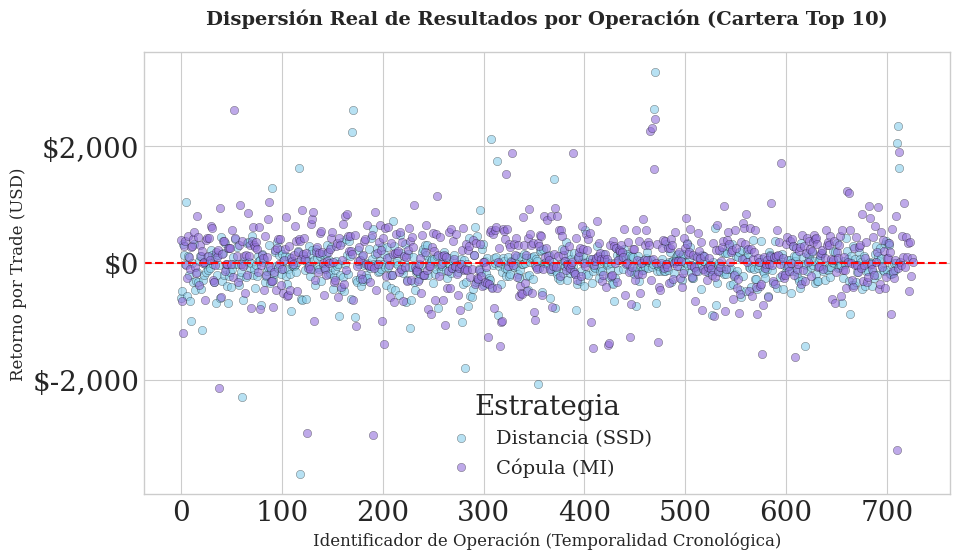

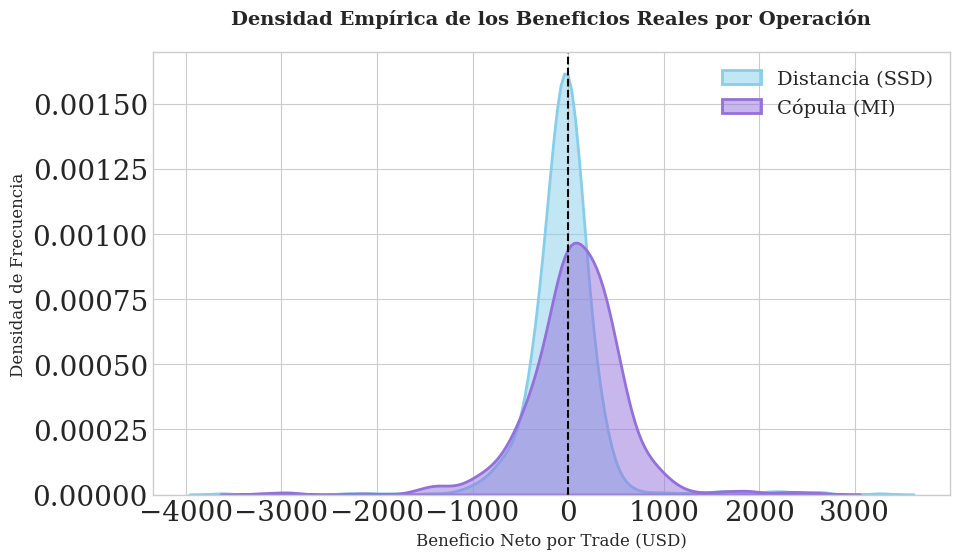

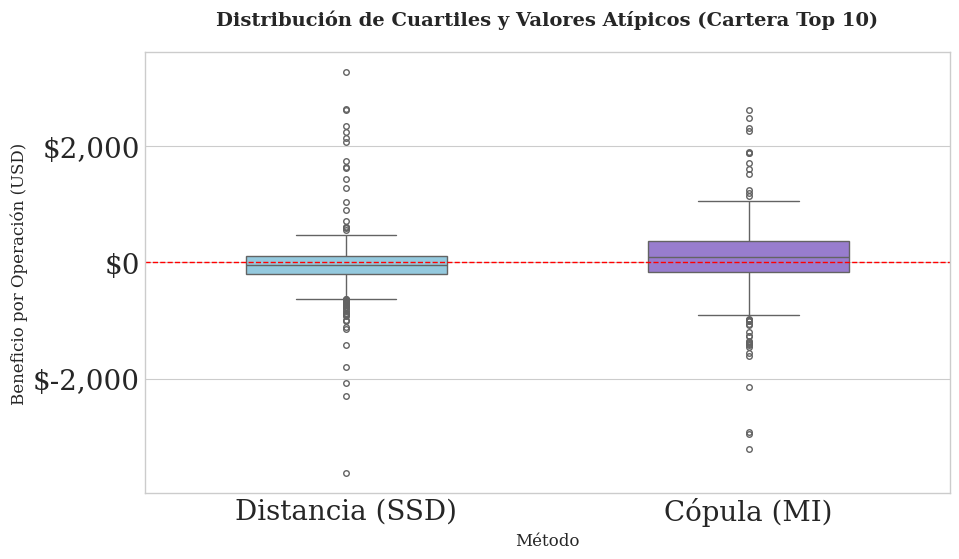

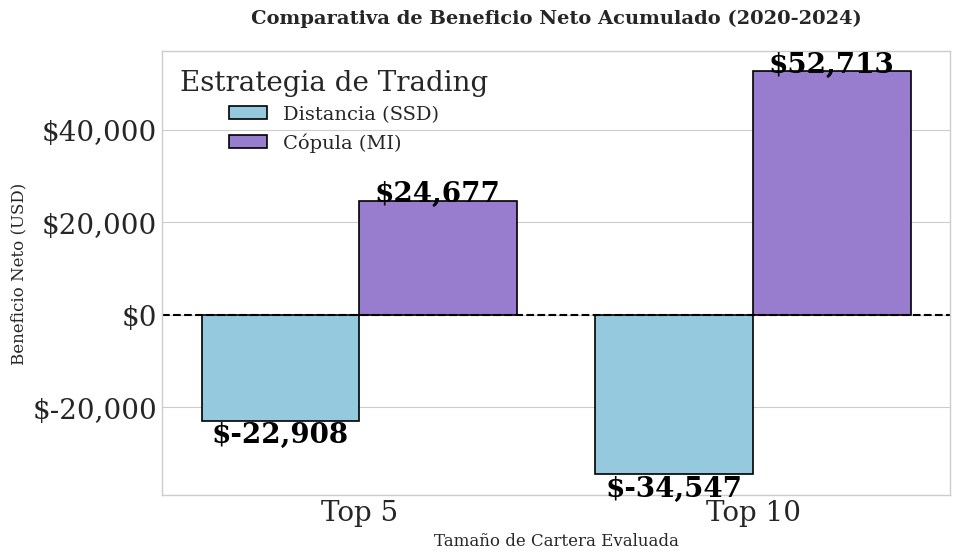

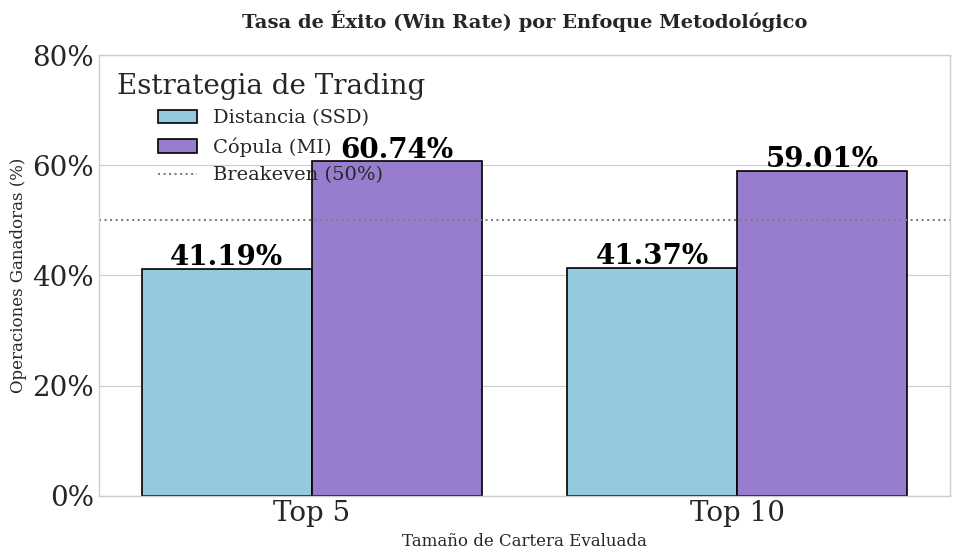

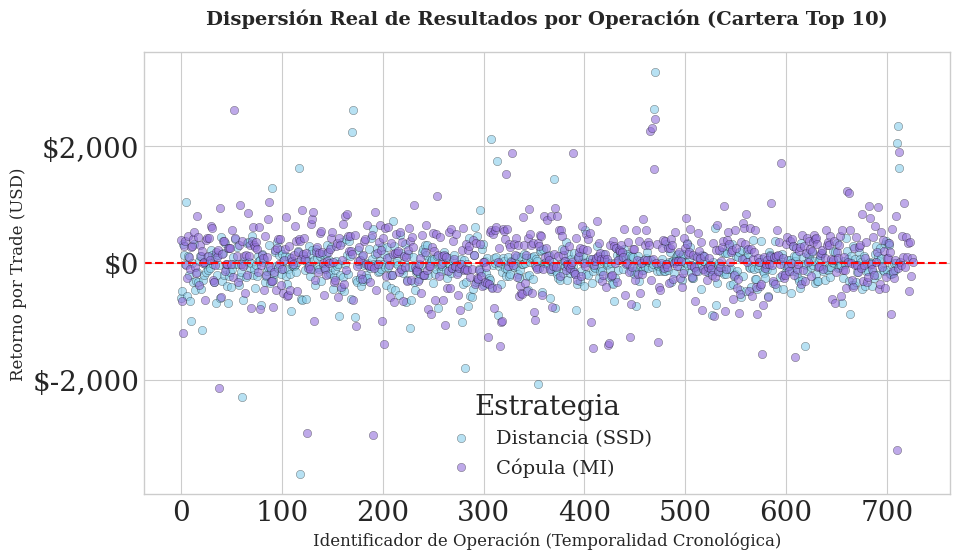

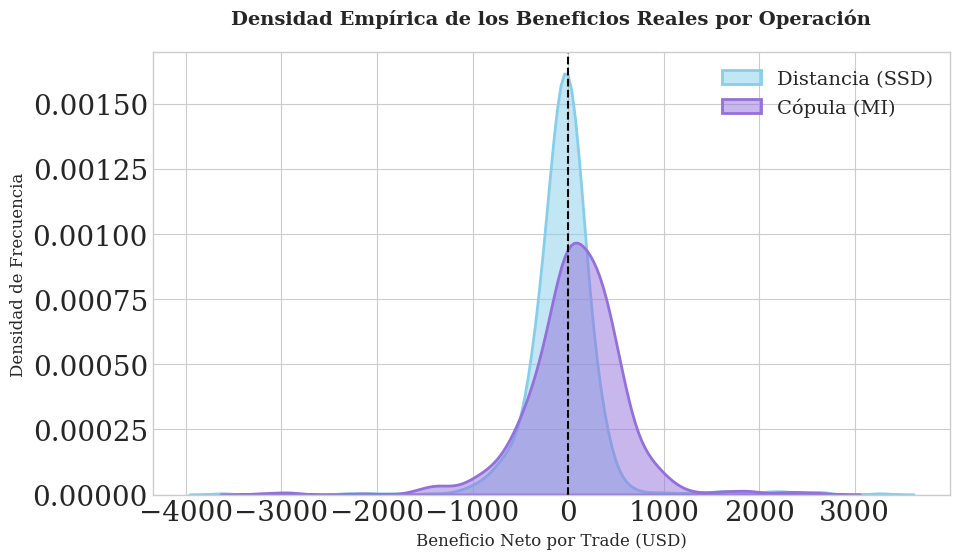

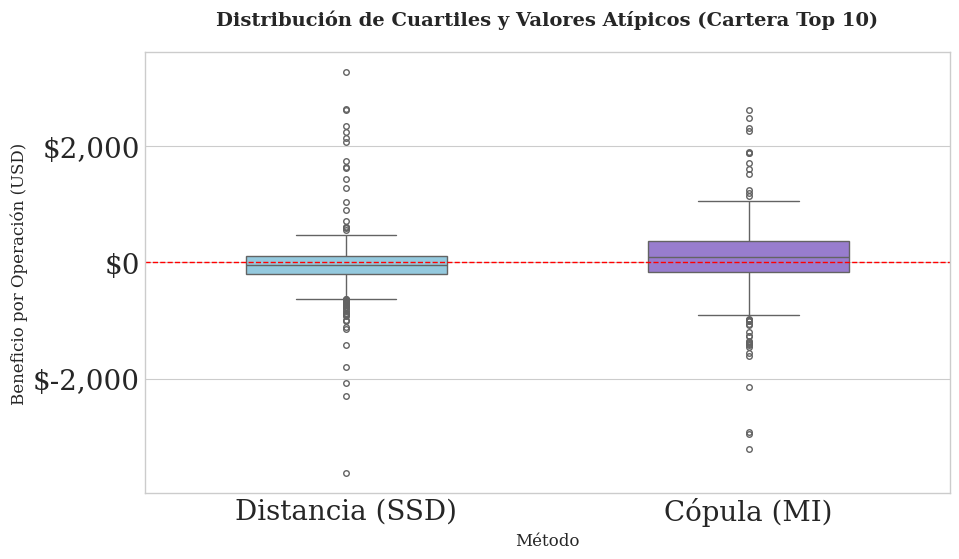


--- CÓDIGO LATEX PARA LA TABLA DE HALLAZGOS EMPÍRICOS ---

\begin{table}[h!]
\centering
\caption{Comparativa de Rendimiento: Método de Distancia vs. Cópula Mixta (2020-2024)}
\label{tab:resultados_finales}
\begin{tabular}{@{}llrrr@{}}
\toprule
\textbf{Estrategia} & \textbf{Cartera} & \textbf{Operaciones} & \textbf{Win Rate (\%)} & \textbf{Beneficio Neto (USD)} \ 
\midrule
Distancia (SSD) & Top 5 & 471 & 41.19\% & \textcolor{red}{\$-22,908.01} \ 
Cópula (MI) & Top 5 & 377 & 60.74\% & \$24,676.99 \ 
\midrule
Distancia (SSD) & Top 10 & 713 & 41.37\% & \textcolor{red}{\$-34,547.20} \ 
Cópula (MI) & Top 10 & 727 & 59.01\% & \$52,713.34 \ 
\bottomrule
\end{tabular}
\end{table}


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter

df_dist = pd.DataFrame(registro_trades_distancia)
df_cop = pd.DataFrame(registro_trades_copula)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12


color_distancia = '#87CEEB'
color_copula = '#9370DB'


resultados = []
for n in TOP_PARES_EVALUAR:
    # Datos para Distancia
    d_sub = df_dist[df_dist['Top'] == n]
    if not d_sub.empty:
        total_ops_dist = len(d_sub)
        resultados.append({
            'Método': 'Distancia (SSD)', 'Cartera': f'Top {n}',
            'Operaciones': total_ops_dist,
            'Win_Rate': (len(d_sub[d_sub['Profit'] > 0]) / total_ops_dist * 100),
            'Profit': d_sub['Profit'].sum()
        })
    # Datos para Cópula
    c_sub = df_cop[df_cop['Top'] == n]
    if not c_sub.empty:
        total_ops_cop = len(c_sub)
        resultados.append({
            'Método': 'Cópula (MI)', 'Cartera': f'Top {n}',
            'Operaciones': total_ops_cop,
            'Win_Rate': (len(c_sub[c_sub['Profit'] > 0]) / total_ops_cop * 100),
            'Profit': c_sub['Profit'].sum()
        })

df_res = pd.DataFrame(resultados)


def format_dollars(x, pos):
    return f'${x:,.0f}'

def format_percent(x, pos):
    return f'{x:.0f}%'

def graficar_profit_comparativo(df):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=df, x='Cartera', y='Profit', hue='Método',
        palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula},
        edgecolor='black', linewidth=1.2, ax=ax
    )

    # Línea base en 0
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_title('Comparativa de Beneficio Neto Acumulado (2020-2024)', pad=20, fontweight='bold')
    ax.set_ylabel('Beneficio Neto (USD)')
    ax.set_xlabel('Tamaño de Cartera Evaluada')
    ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))

    # Añadir valores numéricos sobre las barras
    for p in ax.patches:
        height = p.get_height()
        if height == 0: continue
        y_offset = 1500 if height > 0 else -3000
        ax.annotate(f'${height:,.0f}',
                    (p.get_x() + p.get_width() / 2., height + y_offset),
                    ha='center', va='center', fontweight='bold', color='black')

    plt.legend(title='Estrategia de Trading')
    plt.tight_layout()
    plt.show()

#
# 2. GRÁFICO DE BARRAS AGRUPADAS: TASA DE ÉXITO (WIN RATE)
#
def graficar_win_rate(df):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.barplot(
        data=df, x='Cartera', y='Win_Rate', hue='Método',
        palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula},
        edgecolor='black', linewidth=1.2, ax=ax
    )

    ax.axhline(50, color='gray', linewidth=1.5, linestyle=':', label='Breakeven (50%)')

    ax.set_title('Tasa de Éxito (Win Rate) por Enfoque Metodológico', pad=20, fontweight='bold')
    ax.set_ylabel('Operaciones Ganadoras (%)')
    ax.set_xlabel('Tamaño de Cartera Evaluada')
    ax.yaxis.set_major_formatter(FuncFormatter(format_percent))
    ax.set_ylim(0, 80)

    for p in ax.patches:
        height = p.get_height()
        if height == 0: continue
        ax.annotate(f'{height:.2f}%',
                    (p.get_x() + p.get_width() / 2., height + 2),
                    ha='center', va='center', fontweight='bold', color='black')

    plt.legend(title='Estrategia de Trading', loc='upper left')
    plt.tight_layout()
    plt.show()



# Vamos a aislar los datos de la cartera Top 10 para los gráficos de detalle
cartera_analisis = 10
df_dist_real = df_dist[df_dist['Top'] == cartera_analisis].copy()
df_cop_real = df_cop[df_cop['Top'] == cartera_analisis].copy()

#
# 3. GRÁFICO DE DISPERSIÓN
#
def graficar_scatter_real(df_d, df_c):
    fig, ax = plt.subplots(figsize=(10, 6))

    profit_dist = df_d['Profit'].reset_index(drop=True)
    profit_cop = df_c['Profit'].reset_index(drop=True)

    sns.scatterplot(x=profit_dist.index, y=profit_dist, color=color_distancia,
                    alpha=0.6, label='Distancia (SSD)', edgecolor='black', linewidth=0.3)
    sns.scatterplot(x=profit_cop.index, y=profit_cop, color=color_copula,
                    alpha=0.6, label='Cópula (MI)', edgecolor='black', linewidth=0.3)

    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')

    ax.set_title(f'Dispersión Real de Resultados por Operación (Cartera Top {cartera_analisis})', pad=20, fontweight='bold')
    ax.set_ylabel('Retorno por Trade (USD)')
    ax.set_xlabel('Identificador de Operación (Temporalidad Cronológica)')
    ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))

    plt.legend(title='Estrategia')
    plt.tight_layout()
    plt.show()

#
# 4. HISTOGRAMA / DENSIDAD
#
def graficar_histograma_real(df_d, df_c):
    fig, ax = plt.subplots(figsize=(10, 6))

    sns.kdeplot(df_d['Profit'], color=color_distancia, fill=True, alpha=0.5, label='Distancia (SSD)', linewidth=2)
    sns.kdeplot(df_c['Profit'], color=color_copula, fill=True, alpha=0.5, label='Cópula (MI)', linewidth=2)

    ax.axvline(0, color='black', linestyle='--')

    ax.set_title('Densidad Empírica de los Beneficios Reales por Operación', pad=20, fontweight='bold')
    ax.set_ylabel('Densidad de Frecuencia')
    ax.set_xlabel('Beneficio Neto por Trade (USD)')

    plt.legend()
    plt.tight_layout()
    plt.show()

#
# 5. DIAGRAMA DE CAJAS (BOXPLOT)
#
def graficar_boxplot_real(df_d, df_c):
    fig, ax = plt.subplots(figsize=(10, 6))

    # Preparamos un DataFrame combinado
    df_d.loc[:, 'Método'] = 'Distancia (SSD)'
    df_c.loc[:, 'Método'] = 'Cópula (MI)'
    df_combinado = pd.concat([df_d, df_c])

    sns.boxplot(x='Método', y='Profit', hue='Método', data=df_combinado,
                palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula},
                ax=ax, width=0.5, fliersize=4, legend=False)

    ax.axhline(0, color='red', linestyle='--', linewidth=1)

    ax.set_title(f'Distribución de Cuartiles y Valores Atípicos (Cartera Top {cartera_analisis})', pad=20, fontweight='bold')
    ax.set_ylabel('Beneficio por Operación (USD)')
    ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))

    plt.tight_layout()
    plt.show()


graficar_scatter_real(df_dist_real, df_cop_real)
graficar_histograma_real(df_dist_real, df_cop_real)
graficar_boxplot_real(df_dist_real, df_cop_real)


def generar_codigo_tabla_latex(df):
    print("\n--- CÓDIGO LATEX PARA LA TABLA DE HALLAZGOS EMPÍRICOS ---\n")
    print("\\begin{table}[h!]")
    print("\\centering")
    print("\\caption{Comparativa de Rendimiento: Método de Distancia vs. Cópula Mixta (2020-2024)}")
    print("\\label{tab:resultados_finales}")
    print("\\begin{tabular}{@{}llrrr@{}}")
    print("\\toprule")
    print("\\textbf{Estrategia} & \\textbf{Cartera} & \\textbf{Operaciones} & \\textbf{Win Rate (\\%)} & \\textbf{Beneficio Neto (USD)} \\ ")
    print("\\midrule")

    for index, row in df.iterrows():
        metodo = row['Método']
        cartera = row['Cartera']
        ops = row['Operaciones']
        wr = f"{row['Win_Rate']:.2f}\\%"
        profit = f"\\${row['Profit']:,.2f}"


        if row['Profit'] < 0:
            profit = f"\\textcolor{{red}}{{{profit}}}"

        print(f"{metodo} & {cartera} & {ops} & {wr} & {profit} \\ ")
        if index == 1:
            print("\\midrule")

    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")


graficar_profit_comparativo(df_res)
graficar_win_rate(df_res)
graficar_scatter_real(df_dist_real, df_cop_real)
graficar_histograma_real(df_dist_real, df_cop_real)
graficar_boxplot_real(df_dist_real, df_cop_real)
generar_codigo_tabla_latex(df_res)


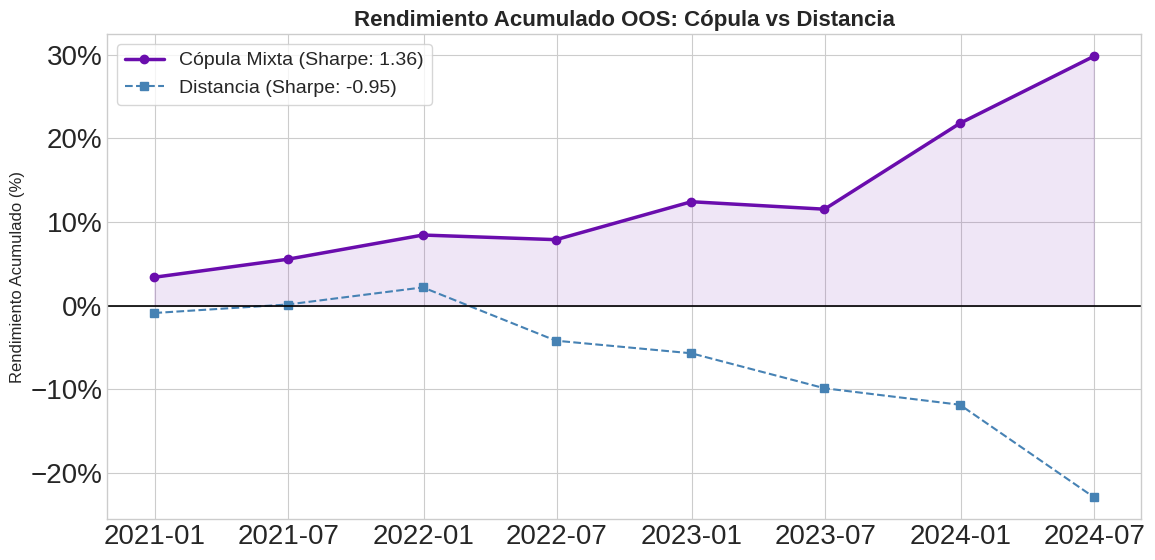

In [ ]:

# 6. GRÁFICA PRINCIPAL: CURVA DE CAPITAL  Y SHARPE

df_dist = pd.DataFrame(registro_trades_distancia)
df_cop = pd.DataFrame(registro_trades_copula)

cartera_n = 5
capital_total = 10000 * 2 * cartera_n

if not df_cop.empty and 'Ventana' in df_cop.columns:
    df_cop['Ventana'] = pd.to_datetime(df_cop['Ventana'])
    df_dist['Ventana'] = pd.to_datetime(df_dist['Ventana'])

    ret_periodo_cop = df_cop[df_cop['Top'] == cartera_n].groupby('Ventana')['Profit'].sum() / capital_total
    ret_periodo_dist = df_dist[df_dist['Top'] == cartera_n].groupby('Ventana')['Profit'].sum() / capital_total

    eq_copula = ret_periodo_cop.cumsum()
    eq_distancia = ret_periodo_dist.cumsum()

    # Sharpe (Anualizado)
    sharpe_cop = (ret_periodo_cop.mean() / ret_periodo_cop.std()) * np.sqrt(2) if ret_periodo_cop.std() != 0 else 0
    sharpe_dist = (ret_periodo_dist.mean() / ret_periodo_dist.std()) * np.sqrt(2) if ret_periodo_dist.std() != 0 else 0

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(eq_copula.index, eq_copula, label=f'Cópula Mixta (Sharpe: {sharpe_cop:.2f})', color='#6A0DAD', linewidth=2.5, marker='o')
    ax.plot(eq_distancia.index, eq_distancia, label=f'Distancia (Sharpe: {sharpe_dist:.2f})', color='#4682B4', linestyle='--', marker='s')

    ax.fill_between(eq_copula.index, eq_copula, 0, color='#6A0DAD', alpha=0.1)
    ax.axhline(0, color='black', linewidth=1.2)
    ax.set_title('Rendimiento Acumulado OOS: Cópula vs Distancia', fontsize=16, fontweight='bold')
    ax.set_ylabel('Rendimiento Acumulado (%)')
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.legend(loc='upper left', frameon=True, facecolor='white')
    plt.tight_layout()
    plt.show()
else:
    print("Error: No hay datos suficientes para graficar. Asegúrate de correr el bucle primero.")

In [ ]:
# ESTADÍSTICAS DESCRIPTIVAS DE LOS TRADES (TOP 10)
def generar_estadisticas_descriptivas(df_d, df_c):
    print(f"\n ESTADÍSTICAS DESCRIPTIVAS DE OPERACIONES INDIVIDUALES (Cartera Top {cartera_analisis}) ")
    print("="*75)

    # Extraemos solo la columna de ganancias/pérdidas
    stats_dist = df_d['Profit'].describe()
    stats_cop = df_c['Profit'].describe()

    # Unimos ambas en un solo cuadro para comparar fácilmente
    df_stats = pd.DataFrame({
        'Método Distancia (SSD)': stats_dist,
        'Cópula Mixta (MI)': stats_cop
    })

    df_stats = df_stats.applymap(lambda x: f"${x:,.2f}" if pd.notnull(x) else "")

    print(df_stats)
    print("="*75)

generar_estadisticas_descriptivas(df_dist_real, df_cop_real)


 ESTADÍSTICAS DESCRIPTIVAS DE OPERACIONES INDIVIDUALES (Cartera Top 10) 
      Método Distancia (SSD) Cópula Mixta (MI)
count                $713.00           $720.00
mean                 $-48.45            $61.15
std                  $434.06           $526.74
min               $-3,617.69        $-3,483.02
25%                 $-194.14          $-189.21
50%                  $-41.90            $77.95
75%                  $100.69           $345.20
max                $3,268.00         $2,473.45


/tmp/ipykernel_3703/537532429.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_stats = df_stats.applymap(lambda x: f"${x:,.2f}" if pd.notnull(x) else "")


# GRAFICOS

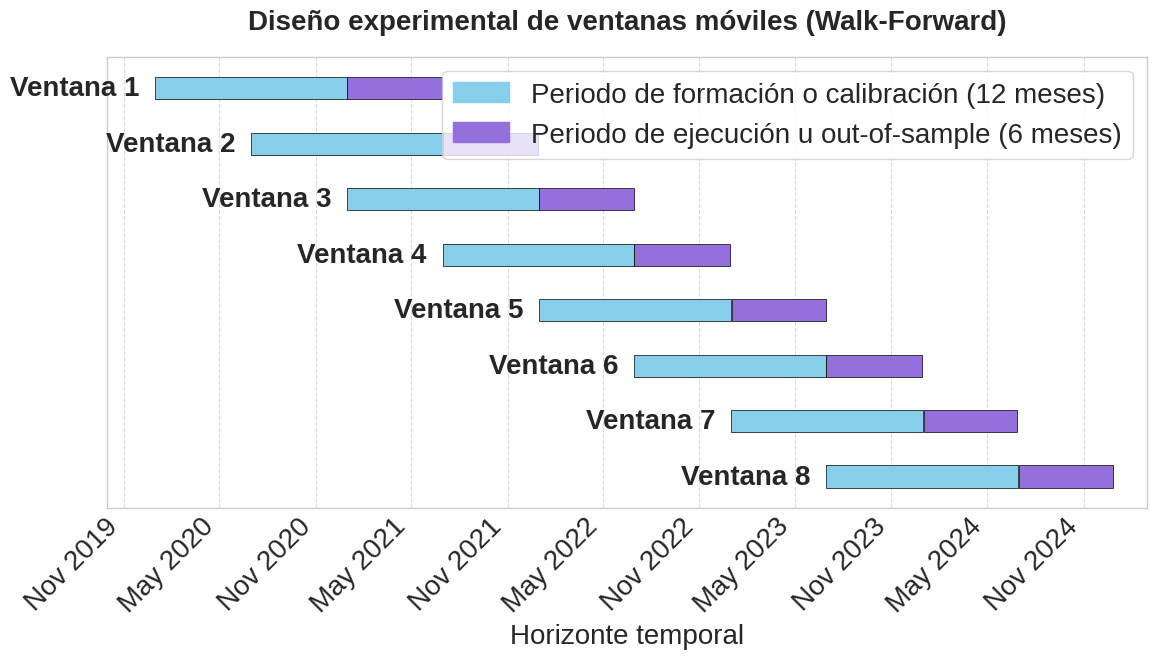

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from datetime import datetime

#
# DIAGRAMA DE VENTANAS MÓVILES
#

# Datos exactos extraídos de la consola del backtesting
ventanas_data = [
    {"id": "Ventana 1", "f_ini": "2019-12-31", "f_fin": "2020-12-31", "t_ini": "2020-12-31", "t_fin": "2021-06-29"},
    {"id": "Ventana 2", "f_ini": "2020-06-30", "f_fin": "2021-06-30", "t_ini": "2021-06-30", "t_fin": "2021-12-29"},
    {"id": "Ventana 3", "f_ini": "2020-12-31", "f_fin": "2021-12-31", "t_ini": "2021-12-31", "t_fin": "2022-06-29"},
    {"id": "Ventana 4", "f_ini": "2021-06-30", "f_fin": "2022-06-30", "t_ini": "2022-06-30", "t_fin": "2022-12-29"},
    {"id": "Ventana 5", "f_ini": "2021-12-31", "f_fin": "2022-12-31", "t_ini": "2023-01-02", "t_fin": "2023-06-29"},
    {"id": "Ventana 6", "f_ini": "2022-06-30", "f_fin": "2023-06-30", "t_ini": "2023-06-30", "t_fin": "2023-12-29"},
    {"id": "Ventana 7", "f_ini": "2022-12-31", "f_fin": "2023-12-31", "t_ini": "2024-01-02", "t_fin": "2024-06-28"},
    {"id": "Ventana 8", "f_ini": "2023-06-30", "f_fin": "2024-06-30", "t_ini": "2024-07-01", "t_fin": "2024-12-27"}
]

# Configuración del gráfico
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

color_formacion = '#87CEEB'
color_trading = '#9370DB'

y_pos = 10
alt_barra = 4

for v in reversed(ventanas_data):
    f_ini = mdates.date2num(datetime.strptime(v["f_ini"], "%Y-%m-%d"))
    f_fin = mdates.date2num(datetime.strptime(v["f_fin"], "%Y-%m-%d"))
    t_ini = mdates.date2num(datetime.strptime(v["t_ini"], "%Y-%m-%d"))
    t_fin = mdates.date2num(datetime.strptime(v["t_fin"], "%Y-%m-%d"))

    # Barra de Formación (12 meses)
    ax.broken_barh([(f_ini, f_fin - f_ini)], (y_pos, alt_barra),
                   facecolors=color_formacion, edgecolor='black', linewidth=0.5)

    # Barra de Trading (6 meses)
    ax.broken_barh([(t_ini, t_fin - t_ini)], (y_pos, alt_barra),
                   facecolors=color_trading, edgecolor='black', linewidth=0.5)

    # Etiqueta de la ventana en el eje Y
    ax.text(f_ini - 30, y_pos + (alt_barra/2), v["id"],
            va='center', ha='right', fontsize=20, fontweight='bold')

    y_pos += 10

# Formato del eje X (Fechas cronológicas)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right', fontsize=20)

ax.set_yticks([])

# Títulos y detalles
ax.set_title('Diseño experimental de ventanas móviles (Walk-Forward)', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel('Horizonte temporal', fontsize=20)

import matplotlib.patches as mpatches
patch_formacion = mpatches.Patch(color=color_formacion, label='Periodo de formación o calibración (12 meses)')
patch_trading = mpatches.Patch(color=color_trading, label='Periodo de ejecución u out-of-sample (6 meses)')
ax.legend(handles=[patch_formacion, patch_trading], loc='upper right', frameon=True, fontsize=20)

ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.yaxis.grid(False)

# Límites del gráfico
fecha_min = mdates.date2num(datetime.strptime("2019-10-01", "%Y-%m-%d"))
fecha_max = mdates.date2num(datetime.strptime("2025-03-01", "%Y-%m-%d"))
ax.set_xlim(fecha_min, fecha_max)

plt.tight_layout()
plt.show()

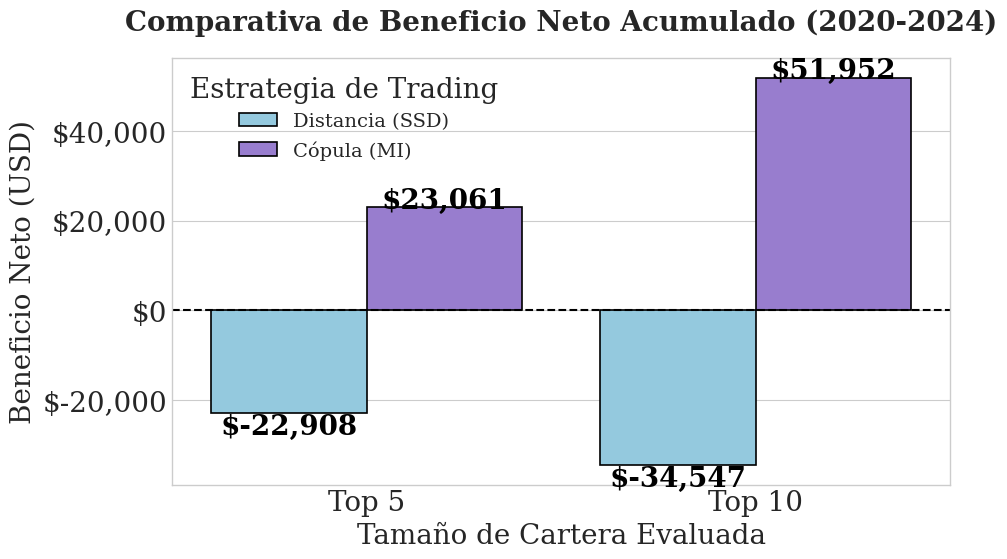

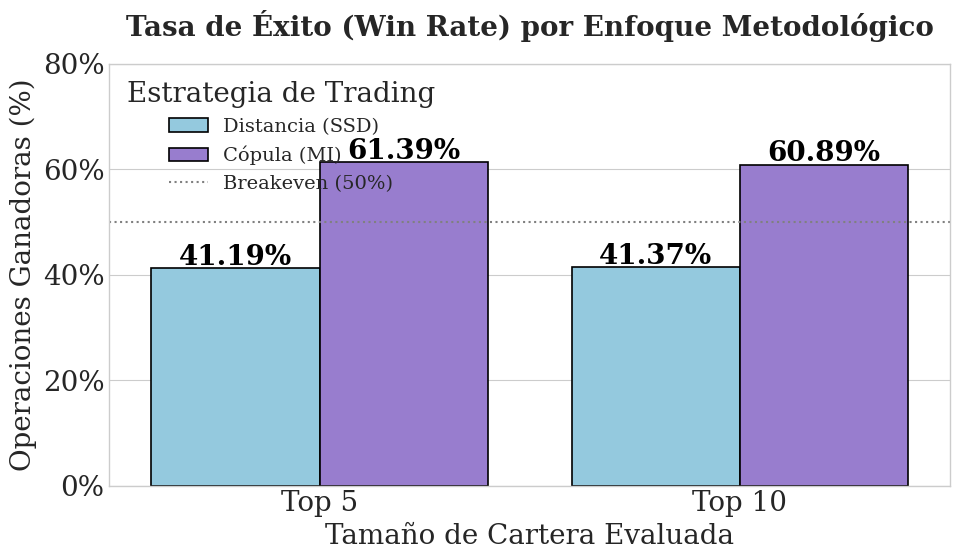

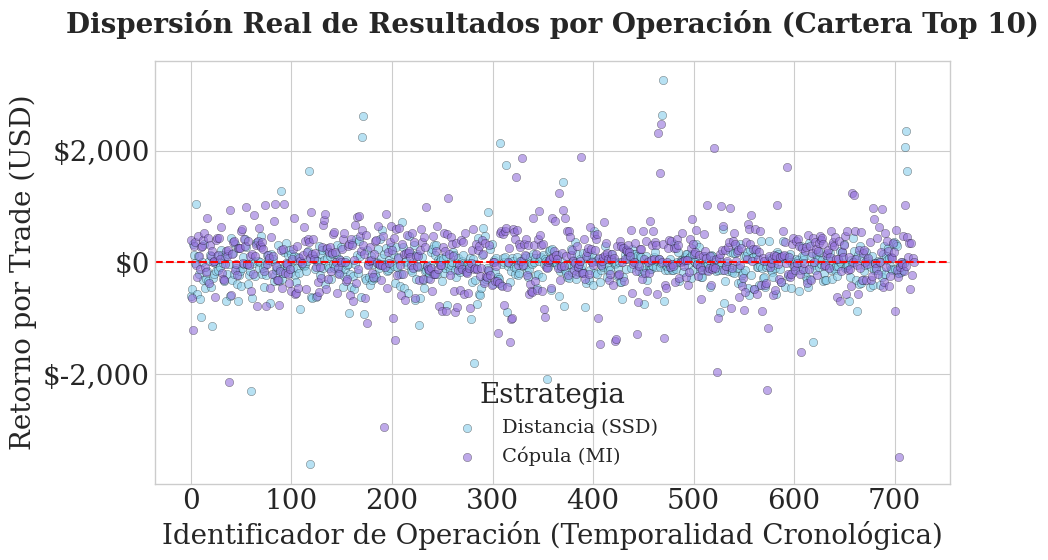

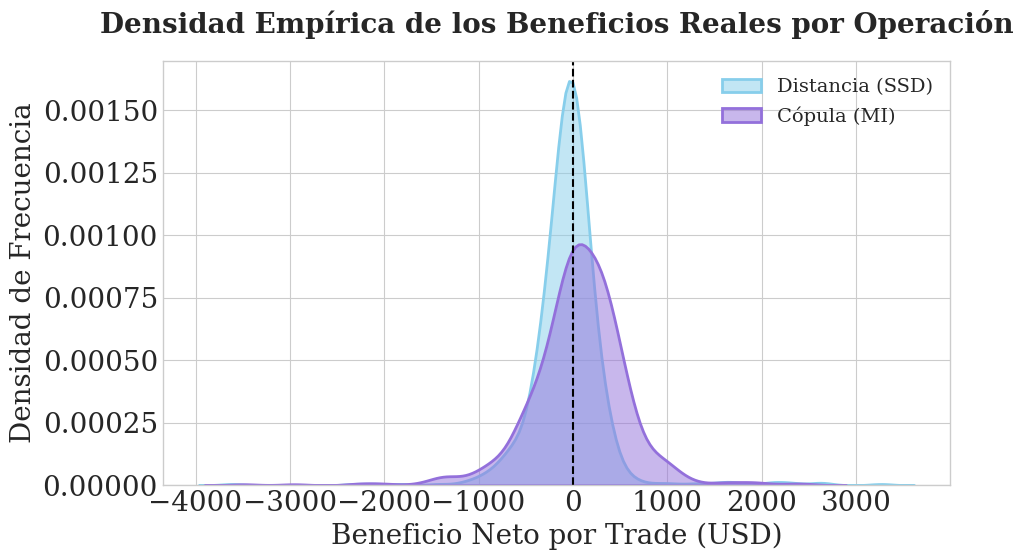

/tmp/ipykernel_3703/3923864992.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Método', y='Profit', data=df_combinado, palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula}, ax=ax, width=0.5, fliersize=4)


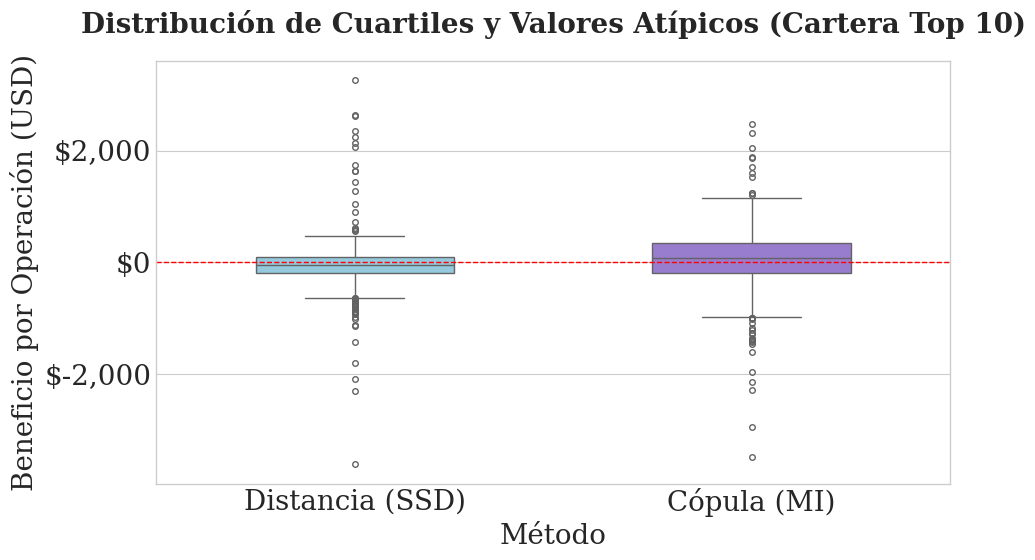

In [ ]:
##corerccion
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import FuncFormatter


plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'serif'

plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.title_fontsize'] = 20

color_distancia = '#87CEEB'
color_copula = '#9370DB'

def graficar_profit_comparativo(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df, x='Cartera', y='Profit', hue='Método',
                palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula},
                edgecolor='black', linewidth=1.2, ax=ax)
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax.set_title('Comparativa de Beneficio Neto Acumulado (2020-2024)', pad=20, fontweight='bold')
    ax.set_ylabel('Beneficio Neto (USD)')
    ax.set_xlabel('Tamaño de Cartera Evaluada')
    ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))
    for p in ax.patches:
        height = p.get_height()
        if height == 0: continue
        y_offset = 1500 if height > 0 else -3000
        ax.annotate(f'${height:,.0f}', (p.get_x() + p.get_width() / 2., height + y_offset),
                    ha='center', va='center', fontweight='bold', color='black')
    plt.legend(title='Estrategia de Trading')
    plt.tight_layout()
    plt.show()

def graficar_win_rate(df):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df, x='Cartera', y='Win_Rate', hue='Método',
                palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula},
                edgecolor='black', linewidth=1.2, ax=ax)
    ax.axhline(50, color='gray', linewidth=1.5, linestyle=':', label='Breakeven (50%)')
    ax.set_title('Tasa de Éxito (Win Rate) por Enfoque Metodológico', pad=20, fontweight='bold')
    ax.set_ylabel('Operaciones Ganadoras (%)')
    ax.set_xlabel('Tamaño de Cartera Evaluada')
    ax.yaxis.set_major_formatter(FuncFormatter(format_percent))
    ax.set_ylim(0, 80)
    for p in ax.patches:
        height = p.get_height()
        if height == 0: continue
        ax.annotate(f'{height:.2f}%', (p.get_x() + p.get_width() / 2., height + 2),
                    ha='center', va='center', fontweight='bold', color='black')
    plt.legend(title='Estrategia de Trading', loc='upper left')
    plt.tight_layout()
    plt.show()

def graficar_scatter_real(df_d, df_c):
    fig, ax = plt.subplots(figsize=(10, 6))
    profit_dist = df_d['Profit'].reset_index(drop=True)
    profit_cop = df_c['Profit'].reset_index(drop=True)
    sns.scatterplot(x=profit_dist.index, y=profit_dist, color=color_distancia, alpha=0.6, label='Distancia (SSD)', edgecolor='black', linewidth=0.3)
    sns.scatterplot(x=profit_cop.index, y=profit_cop, color=color_copula, alpha=0.6, label='Cópula (MI)', edgecolor='black', linewidth=0.3)
    ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'Dispersión Real de Resultados por Operación (Cartera Top {cartera_analisis})', pad=20, fontweight='bold')
    ax.set_ylabel('Retorno por Trade (USD)')
    ax.set_xlabel('Identificador de Operación (Temporalidad Cronológica)')
    ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))
    plt.legend(title='Estrategia')
    plt.tight_layout()
    plt.show()

def graficar_histograma_real(df_d, df_c):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.kdeplot(df_d['Profit'], color=color_distancia, fill=True, alpha=0.5, label='Distancia (SSD)', linewidth=2)
    sns.kdeplot(df_c['Profit'], color=color_copula, fill=True, alpha=0.5, label='Cópula (MI)', linewidth=2)
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title('Densidad Empírica de los Beneficios Reales por Operación', pad=20, fontweight='bold')
    ax.set_ylabel('Densidad de Frecuencia')
    ax.set_xlabel('Beneficio Neto por Trade (USD)')
    plt.legend()
    plt.tight_layout()
    plt.show()

def graficar_boxplot_real(df_d, df_c):
    fig, ax = plt.subplots(figsize=(10, 6))
    df_d.loc[:, 'Método'] = 'Distancia (SSD)'
    df_c.loc[:, 'Método'] = 'Cópula (MI)'
    df_combinado = pd.concat([df_d, df_c])
    sns.boxplot(x='Método', y='Profit', data=df_combinado, palette={'Distancia (SSD)': color_distancia, 'Cópula (MI)': color_copula}, ax=ax, width=0.5, fliersize=4)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'Distribución de Cuartiles y Valores Atípicos (Cartera Top {cartera_analisis})', pad=20, fontweight='bold')
    ax.set_ylabel('Beneficio por Operación (USD)')
    ax.yaxis.set_major_formatter(FuncFormatter(format_dollars))
    plt.tight_layout()
    plt.show()



graficar_profit_comparativo(df_res)
graficar_win_rate(df_res)
graficar_scatter_real(df_dist_real, df_cop_real)
graficar_histograma_real(df_dist_real, df_cop_real)
graficar_boxplot_real(df_dist_real, df_cop_real)
